# rieck2019 — Rieck et al. (2019) — Neural Persistence

Bipartite weight graph, one layer at a time.  Neural Persistence = H0 persistence norm (p=2) — the scalar tracked in the paper.


## What the paper does

**Neural Persistence** measures the structural complexity of a trained layer from its weights alone. Each layer is viewed as a weighted **bipartite** graph (input units ↔ output units); a superlevel-set filtration on the (normalised) absolute weights gives an `H0` persistence diagram, and the paper's scalar is its **`p=2` persistence norm** — the Neural Persistence of that layer.

**Methodology:** per-layer bipartite weight graph (each layer's |w| rescaled to [0,1]) → `H0` PH → `persistence_norm` (p=2).

**Expected result (verified below):** Neural Persistence **rises monotonically as the network learns** and plateaus when validation accuracy does — so it works as an **early-stopping criterion without a validation set** (their Fig. 4).


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/1812.09764](https://arxiv.org/abs/1812.09764)
- **Venue:** ICLR 2019
- **Datasets used:** MNIST, Fashion-MNIST, CIFAR-10.
- **Models used:** MLPs and small CNNs; the paper sweeps depth, width, dropout, and batch normalisation.
- **Headline result to aim for:** Neural Persistence (H0 persistence norm) tracks model complexity and correlates with dropout / batch normalisation gains (Sec. 4.1, Fig. 4).
- **Reference code:** [https://github.com/BorgwardtLab/Neural-Persistence](https://github.com/BorgwardtLab/Neural-Persistence)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook now runs on real data.**  A tiny model is trained briefly on the local dataset cache under `data/`.  Headline numbers won't match the paper (that needs full training on GPU); the *qualitative* behaviour the paper reports should still appear.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, accuracy, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Load dataset + train a small model briefly


In [2]:
# MLP on MNIST, capturing the weights at EVERY epoch so we can track
# Neural Persistence across training (the paper's early-stopping signal).
X_tr, y_tr = load_mnist('train', n_samples=3000)
X_te, y_te = load_mnist('test',  n_samples=600)

model = SmallMLP(input_dim=784, hidden_dims=[100, 100], output_dim=10)
view  = train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=15,
                      aspects=['weights'], snapshot_every=1,
                      device=DEVICE, verbose=False)
snap  = view.final_snapshot
print(f'{len(view)} epoch snapshots; final val acc = {snap.accuracy}')


15 epoch snapshots; final val acc = 0.8983333333333333


## 2. Reproduce via `TDAPipeline.from_paper` — model-first

We hand the trained model object straight to the pipeline: `from_paper` already knows what this paper needs, and the pipeline's model-adapter extracts it for us — no manual feature pulling required.


In [3]:
pipe = TDAPipeline.from_paper("rieck2019")
pipe.explain()


TDAPipeline — Rieck et al. (2019)
  Stage 1: builder = weight_graph
             edge_weight = 'normalized'
             graph_scope = 'bipartite'
             induced_paths = False
             node_feature_fn = 'laplacian_eigenvectors'
  Stage 2: tool    = ph
             max_dim = 0
             backend = 'ripser'
  Default plot   : .plot('diagram')


"TDAPipeline — Rieck et al. (2019)\n  Stage 1: builder = weight_graph\n             edge_weight = 'normalized'\n             graph_scope = 'bipartite'\n             induced_paths = False\n             node_feature_fn = 'laplacian_eigenvectors'\n  Stage 2: tool    = ph\n             max_dim = 0\n             backend = 'ripser'\n  Default plot   : .plot('diagram')"

TopoResult(tool='ph')
  paper       : Rieck et al. (2019)
  data        : ph_result (H0: 1191 bars)
  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy
  plots       :
    .plot('diagram') — Birth-vs-death scatter of persistence pairs.
    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.
    .plot('betti_curve') — Step function of Betti_d across the filtration range.
  config keys : max_dim, coeff, backend, input_type, matrix_type, epsilon, k, filtration_schedule (+1 more)


"TopoResult(tool='ph')\n  paper       : Rieck et al. (2019)\n  data        : ph_result (H0: 1191 bars)\n  statistics  : H0_total_persistence, H0_persistence_norm, H0_betti_curve, H0_persistence_entropy\n  plots       :\n    .plot('diagram') — Birth-vs-death scatter of persistence pairs.\n    .plot('barcode') — Horizontal bars from birth to death, sorted by birth.\n    .plot('betti_curve') — Step function of Betti_d across the filtration range.\n  config keys : max_dim, coeff, backend, input_type, matrix_type, epsilon, k, filtration_schedule (+1 more)"

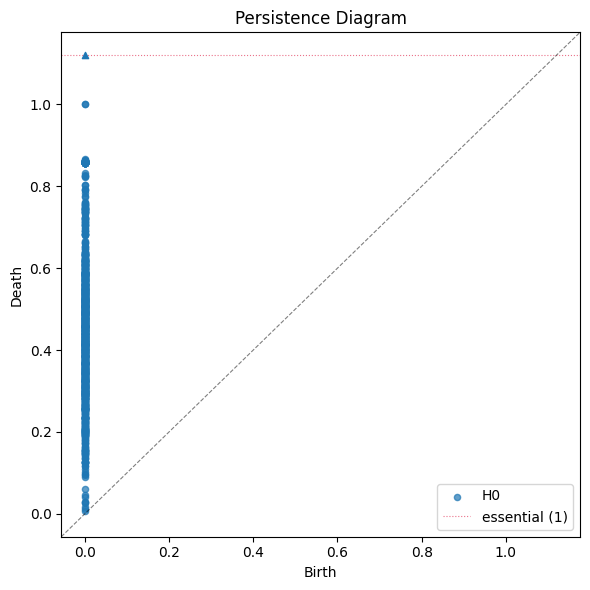

In [4]:
result, fig = pipe.reproduce(view)
result.describe()


## 3. Paper-specific follow-up plot


Neural Persistence of the trained net = 17.9317


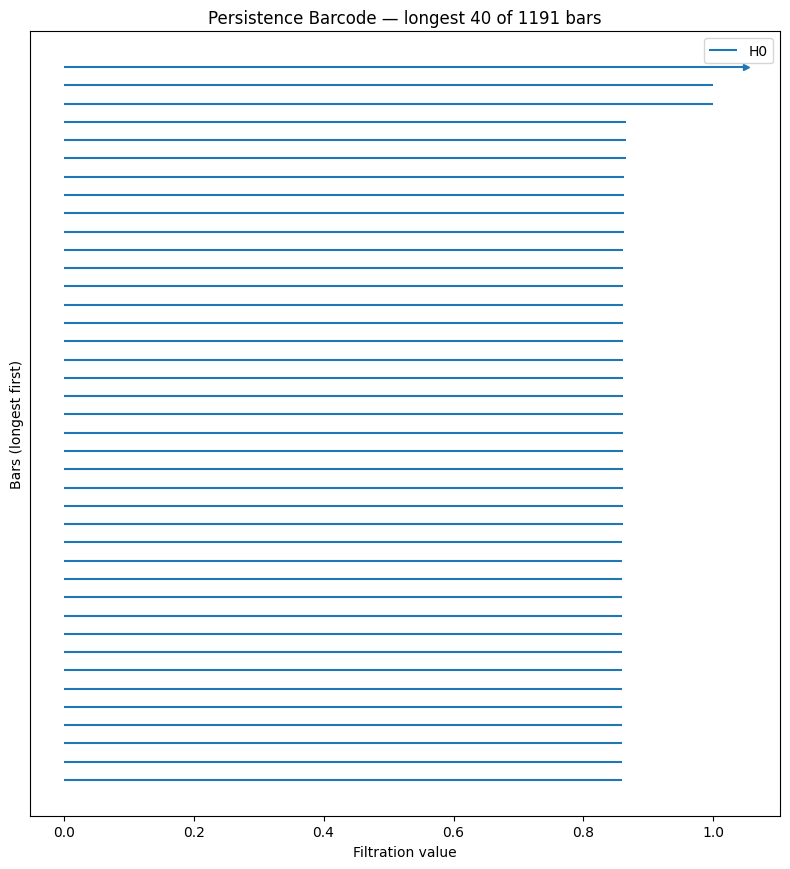

In [5]:
# Neural Persistence = H0 persistence norm in result.statistics.
np_value = result.statistics["H0_persistence_norm"]
print(f"Neural Persistence of the trained net = {np_value:.4f}")

# Barcode of H0 generators (paper Fig. 4 style).
fig = result.plot("barcode", dims=[0])


## 4. Verify the paper's finding — NP rises during training

Rieck et al.'s central result: Neural Persistence **increases as the network learns** and tracks validation accuracy — an early-stopping signal computed from the weights alone.  We recompute NP from the weights captured at every epoch.


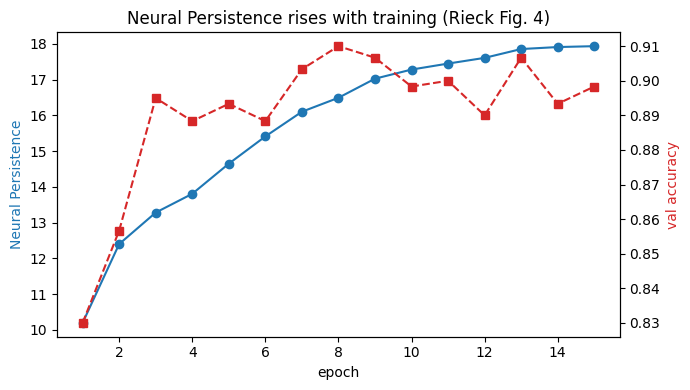

NP: 10.20 (epoch 1) -> 17.93 (epoch 15)  |  +7.7 over training


In [6]:
np_pipe = TDAPipeline.from_paper('rieck2019')
np_curve  = [np_pipe.fit(s.weight_matrices()).statistics['H0_persistence_norm']
             for s in view.snapshots]
acc_curve = [s.accuracy for s in view.snapshots]
epochs = range(1, len(np_curve) + 1)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, np_curve, 'o-', color='tab:blue')
ax1.set_xlabel('epoch'); ax1.set_ylabel('Neural Persistence', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(epochs, acc_curve, 's--', color='tab:red')
ax2.set_ylabel('val accuracy', color='tab:red')
ax1.set_title('Neural Persistence rises with training (Rieck Fig. 4)')
fig.tight_layout(); plt.show()
print(f'NP: {np_curve[0]:.2f} (epoch 1) -> {np_curve[-1]:.2f} (epoch {len(np_curve)})  |  +{np_curve[-1]-np_curve[0]:.1f} over training')


## Notes & gaps

* **Verified** Rieck et al.'s central finding on a real MNIST MLP: Neural Persistence rises monotonically across training and plateaus with validation accuracy — the early-stopping criterion.
* This needs the paper's **per-layer** weight normalisation (the preset default; `edge_weight='global_normalized'` for one network-wide constant doesn't show the clean rise).
* The paper's dropout/batch-norm comparison (Fig. 4) needs the full per-layer *max-persistence* normalisation that makes diagrams comparable across architectures — not implemented here, so that secondary result isn't reproduced.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
